# 13 · Consolidación del grupo **QUESTIONNAIRE**

**Proyecto:** Modelo de longevidad NHANES 2017-2018 (ciclo `_J`)
**Capa:** `01_raw` (.xpt) → **`02_intermediate`** → `03_primary`

## Objetivo
Resumir los **14 cuestionarios** en un dataset intermedio compacto, transformando decenas de
ítems en **scores e indicadores** interpretables (suma de ítems → un número).

**Datasets de este grupo (14):** `smq` (tabaco), `alq` (alcohol), `hsq` (salud autopercibida),
`paq` (actividad física), `pfq` (función física), `dpq` (depresión PHQ-9), `slq` (sueño),
`mcq` (condiciones médicas), `diq` (diabetes), `bpq` (presión/colesterol), `kiq_u` (riñón),
`rxq_rx` (medicamentos), `whq` (historia de peso), `dlq` (discapacidad).

## Decisiones clave
1. **Recodificar códigos especiales NHANES** (`7/77/777/7777` = rechazó, `9/99/999/9999` = no sabe)
   a `NaN` **antes** de cualquier cálculo: son no-respuestas, no números.
2. **Scores compuestos** en vez de ítems sueltos: PHQ-9, índice de comorbilidad, score de
   limitación funcional, MET-min/semana, etc.
3. **Marcadores de enfermedad terminal** (diálisis, polifarmacia, pérdida de peso) se conservan
   pero se **etiquetan como posible *leakage*** para entrenar variantes con/sin ellos.


## 1. Setup

In [1]:
%load_ext kedro.ipython

[06/16/26 19:53:09] INFO     Using 'conf\logging.yml' as logging configuration. You can change this ]8;id=16167568;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\framework\project\__init__.py\__init__.py]8;;\:]8;id=16167569;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\framework\project\__init__.py#281\281]8;;\
                             by setting the KEDRO_LOGGING_CONFIG environment variable accordingly.                 

[06/16/26 19:53:10] INFO     Registered line magic '%reload_kedro'                                   ]8;id=16167576;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=16167577;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py#67\67]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=16167583;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=16167584;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py#69\69]8;;\

                    INFO     Resolved project path as:                                              ]8;id=16167590;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=16167591;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py#193\193]8;;\
                             C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes.                                        
                             To set a different path, run '%reload_kedro <project_root>'                           

[06/16/26 19:53:11] INFO     No typed parameter requirements found, returning original   ]8;id=16167598;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\validation\parameter_validator.py\parameter_validator.py]8;;\:]8;id=16167599;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\validation\parameter_validator.py#124\124]8;;\
                             parameters                                                                            

[06/16/26 19:53:14] INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=16167606;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=16167607;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro_telemetry\plugin.py#273\273]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

[06/16/26 19:53:15] INFO     Kedro project Nhanes                                                   ]8;id=16167613;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=16167614;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py#159\159]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=16167620;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=16167621;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py#160\160]8;;\
                             'pipelines'                                                                           

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 120)
plt.rcParams["figure.dpi"] = 110

PROJ = Path(context.project_path)
OUT_DIR = PROJ / "data" / "02_intermediate"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("Salida:", OUT_DIR)

Salida: C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\data\02_intermediate


## 2. Carga de los 14 cuestionarios

In [3]:
Q_DATASETS = {
    "smq": "smq_j_dataset", "alq": "alq_j_dataset", "hsq": "hsq_j_dataset",
    "paq": "paq_j_dataset", "pfq": "pfq_j_dataset", "dpq": "dpq_j_dataset",
    "slq": "slq_j_dataset", "mcq": "mcq_j_dataset", "diq": "diq_j_dataset",
    "bpq": "bpq_j_dataset", "kiq": "kiq_u_j_dataset", "rxq": "rxq_rx_j_dataset",
    "whq": "whq_j_dataset", "dlq": "dlq_j_dataset",
}
q = {}
for short, name in Q_DATASETS.items():
    q[short] = catalog.load(name)
    print(f"{short:5s} filas={q[short].shape[0]:6d} columnas={q[short].shape[1]:3d}")

[06/16/26 19:53:16] INFO     Loading data from smq_j_dataset (GenericDataset)...               ]8;id=16167628;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=16167629;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

smq   filas=  6724 columnas= 37


[06/16/26 19:53:17] INFO     Loading data from alq_j_dataset (GenericDataset)...               ]8;id=16167634;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=16167635;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

alq   filas=  5533 columnas= 10


                    INFO     Loading data from hsq_j_dataset (GenericDataset)...               ]8;id=16167640;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=16167641;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

...

rxq   filas= 19643 columnas= 13

                    INFO     Loading data from whq_j_dataset (GenericDataset)...               ]8;id=16167700;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=16167701;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

whq   filas=  6161 columnas= 37


                    INFO     Loading data from dlq_j_dataset (GenericDataset)...               ]8;id=16167706;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=16167707;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

dlq   filas=  8897 columnas= 13


## 3. Funciones de recodificación (códigos especiales → `NaN`)

NHANES codifica las no-respuestas como números altos. Si no se limpian, arruinan medias,
escalado e imputación. Definimos utilidades pequeñas y seguras (operan columna a columna).

In [4]:
def s_nan(series, bad):
    # Convierte a NaN los codigos especiales (rechazo / no sabe)
    return series.where(~series.isin(bad))

def yesno(series):
    # 1 = Si -> 1.0 ; 2 = No -> 0.0 ; cualquier otro (7,9,NaN) -> NaN
    return series.map({1: 1.0, 2: 0.0})

def idx(short):
    # Indexa un dataset por SEQN (deduplicado) para alinear por persona
    d = q[short].drop_duplicates("SEQN").copy()
    d["SEQN"] = d["SEQN"].astype("int64")
    return d.set_index("SEQN")

# Codigos especiales tipicos segun la escala del item
BAD_YN  = [7, 9]            # items si/no
BAD_2   = [77, 99]          # escalas de 2 digitos (dias, frecuencia)
BAD_3   = [777, 999]        # cantidades de 3 digitos (cigarrillos, tragos)
BAD_4   = [7777, 9999]      # cantidades de 4 digitos (minutos, peso lb)
print("helpers listos")

helpers listos


## 4. Construcción de features por dominio

Cada bloque toma los ítems crudos de un cuestionario y produce **una o pocas columnas**
con significado clínico. Vamos guardando cada feature como una `Series` indexada por `SEQN`.

In [5]:
F = {}  # diccionario de features (cada valor es una Series indexada por SEQN)

### 4.1 Tabaquismo (SMQ) — estado y cantidad

In [6]:
smq = idx("smq")
smoked100 = yesno(s_nan(smq["SMQ020"], BAD_YN))   # fumó >=100 cigarrillos en la vida
now = s_nan(smq["SMQ040"], BAD_YN)                 # 1=diario, 2=algunos días, 3=no fuma

estatus = pd.Series(index=smq.index, dtype="object")
estatus[smoked100 == 0] = "nunca"
estatus[(smoked100 == 1) & (now == 3)] = "exfumador"
estatus[(smoked100 == 1) & (now.isin([1, 2]))] = "activo"
F["tabaquismo"] = estatus.astype("category")
F["cigarrillos_dia"] = s_nan(smq["SMD650"], BAD_3)   # cigarrillos/día actuales
print(F["tabaquismo"].value_counts(dropna=False))

nunca        3497
exfumador    1338
activo       1021
NaN           868
Name: count, dtype: int64


### 4.2 Alcohol (ALQ)

In [7]:
alq = idx("alq")
F["alcohol_freq_anual"] = s_nan(alq["ALQ121"], BAD_2)  # 0=nunca ... 10=cada día
F["tragos_por_dia"] = s_nan(alq["ALQ130"], BAD_3)
print(F["alcohol_freq_anual"].describe())

count    4.541000e+03
mean     4.911253e+00
std      3.535946e+00
min      5.397605e-79
25%      1.000000e+00
50%      5.000000e+00
75%      8.000000e+00
max      1.000000e+01
Name: ALQ121, dtype: float64

### 4.3 Salud autopercibida (HSQ) — ordinal 1=excelente … 5=mala

In [8]:
hsq = idx("hsq")
F["salud_autopercibida"] = s_nan(hsq["HSD010"], BAD_YN)
print(F["salud_autopercibida"].value_counts(dropna=False).sort_index())

HSD010
1.0     619
2.0    1544
3.0    2454
4.0    1175
5.0     172
NaN    2402
Name: count, dtype: int64


### 4.4 Actividad física (PAQ) — MET-min/semana

Combinamos los dominios de actividad (trabajo vigoroso/moderado, transporte, recreación
vigorosa/moderada) usando sus valores MET (vigoroso = 8, moderado/caminar = 4):

`MET-min/sem = Σ (días/sem × min/día × MET)` por dominio. El umbral OMS de actividad
suficiente es **≥ 600 MET-min/semana**.

In [9]:
paq = idx("paq")
def met_domain(gate, days, mins, met):
    g = yesno(s_nan(paq[gate], BAD_YN))
    dd = s_nan(paq[days], BAD_2)
    mm = s_nan(paq[mins], BAD_4)
    return (dd * mm * met).where(g == 1, 0.0)

dom = (
    met_domain("PAQ605", "PAQ610", "PAD615", 8) +   # trabajo vigoroso
    met_domain("PAQ620", "PAQ625", "PAD630", 4) +   # trabajo moderado
    met_domain("PAQ635", "PAQ640", "PAD645", 4) +   # transporte (caminar/bici)
    met_domain("PAQ650", "PAQ655", "PAD660", 8) +   # recreación vigorosa
    met_domain("PAQ665", "PAQ670", "PAD675", 4)     # recreación moderada
)
F["met_min_semana"] = dom
F["activo_oms"] = (dom >= 600).astype("Int64")
F["sedentario_min"] = s_nan(paq["PAD680"], BAD_4)    # minutos sedentarios/día
print(F["met_min_semana"].describe())

count     5814.000000
mean      4246.784314
std       7083.468430
min          0.000000
25%          0.000000
50%       1320.000000
75%       4800.000000
max      58320.000000
dtype: float64


### 4.5 Función física (PFQ) — score de limitación (ADL/IADL)

`PFQ061A…T` miden la dificultad para 20 actividades (1 = sin dificultad … 4 = incapaz).
Sumamos `(valor − 1)` para obtener un **score 0–60**: más alto = más limitación.

In [10]:
pfq = idx("pfq")
items_pf = [c for c in pfq.columns if c.startswith("PFQ061")]
dif = pfq[items_pf].apply(lambda s: s.where(s.isin([1, 2, 3, 4])) - 1)
F["limitacion_funcional"] = dif.sum(axis=1, min_count=10)  # >=10 de 20 ítems respondidos
print("Ítems de función física:", len(items_pf))
print(F["limitacion_funcional"].describe())

Ítems de función física:

 20


count    2918.000000
mean        7.715901
std         8.422945
min         0.000000
25%         1.000000
50%         5.000000
75%        13.000000
max        46.000000
dtype: float64


### 4.6 Depresión (DPQ) — PHQ-9

Suma de los 9 ítems `DPQ010…DPQ090` (cada uno 0–3) → score **0–27**.
`depresion_flag = 1` si PHQ-9 ≥ 10 (umbral clínico de depresión moderada).

In [11]:
dpq = idx("dpq")
items_phq = [f"DPQ0{n}0" for n in range(1, 10)]   # DPQ010 ... DPQ090
# OJO: read_sas codifica el 0 ("para nada") como ~5.4e-79 (artefacto XPORT).
# Por eso NO usamos isin([0,...]); recodificamos solo 7/9 -> NaN y los ceros (~0) suman bien.
phq = dpq[items_phq].apply(lambda s: s_nan(s, BAD_YN))
F["phq9_score"] = phq.sum(axis=1, min_count=7).round()
F["depresion_flag"] = (F["phq9_score"] >= 10).astype("Int64").where(F["phq9_score"].notna())
print(F["phq9_score"].describe())

count    5086.000000
mean        3.244593
std         4.249396
min         0.000000
25%         0.000000
50%         2.000000
75%         5.000000
max        25.000000
dtype: float64

### 4.7 Sueño (SLQ)

In [12]:
slq = idx("slq")
horas = s_nan(slq["SLD012"], BAD_2)
F["horas_sueno"] = horas.where(horas <= 24)
F["sueno_categoria"] = pd.cut(F["horas_sueno"], bins=[0, 6, 9, 24],
                              labels=["corto", "normal", "largo"]).astype("category")
print(F["sueno_categoria"].value_counts(dropna=False))

SLD012
normal    4228
corto     1118
largo      767
NaN         48
Name: count, dtype: int64


### 4.8 Condiciones médicas (MCQ) — índice de comorbilidad

Contamos cuántas condiciones crónicas reporta el participante y marcamos banderas de
enfermedad cardiovascular y cáncer.

In [13]:
mcq = idx("mcq")
COND = {
    "MCQ160A": "artritis", "MCQ160B": "icc", "MCQ160C": "cardiopatia_coronaria",
    "MCQ160D": "angina", "MCQ160E": "infarto", "MCQ160F": "acv",
    "MCQ160K": "bronquitis_cronica", "MCQ160L": "enf_higado", "MCQ160O": "epoc",
    "MCQ220": "cancer",
}
cond_yn = mcq[list(COND)].apply(yesno)
F["comorbilidad_count"] = cond_yn.sum(axis=1, min_count=5)
F["cvd_flag"] = mcq[["MCQ160B", "MCQ160C", "MCQ160D", "MCQ160E", "MCQ160F"]].apply(yesno).max(axis=1)
F["cancer_flag"] = yesno(s_nan(mcq["MCQ220"], BAD_YN))
F["artritis_flag"] = yesno(mcq["MCQ160A"])
print(F["comorbilidad_count"].describe())

count    5569.000000
mean        0.796373
std         1.201732
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         8.000000
dtype: float64

### 4.9 Diabetes (DIQ)

In [14]:
diq = idx("diq")
dia = s_nan(diq["DIQ010"], BAD_YN)              # 1=sí, 2=no, 3=limítrofe
F["diabetes_flag"] = (dia == 1).astype("Int64").where(dia.notna())
F["diabetes_insulina"] = yesno(s_nan(diq["DIQ050"], BAD_YN))
print(F["diabetes_flag"].value_counts(dropna=False))

DIQ010
0       8000
1        893
<NA>       4
Name: count, dtype: Int64


### 4.10 Hipertensión y colesterol diagnosticados (BPQ)

In [15]:
bpq = idx("bpq")
F["hipertension_dx"] = yesno(s_nan(bpq["BPQ020"], BAD_YN))
F["medicacion_presion"] = yesno(s_nan(bpq["BPQ040A"], BAD_YN))
F["colesterol_alto_dx"] = yesno(s_nan(bpq["BPQ080"], BAD_YN))
F["medicacion_colesterol"] = yesno(s_nan(bpq["BPQ090D"], BAD_YN))
print("hipertensión dx:", F["hipertension_dx"].mean().round(3))

hipertensión dx: 0.347


### 4.11 Enfermedad renal (KIQ) — ⚠️ diálisis = posible leakage

In [16]:
kiq = idx("kiq")
F["enf_renal_dx"] = yesno(s_nan(kiq["KIQ022"], BAD_YN))
F["dialisis_flag"] = yesno(s_nan(kiq["KIQ025"], BAD_YN))   # ⚠️ marcador de enf. terminal
print("diálisis (n):", int((F['dialisis_flag'] == 1).sum()))

diálisis (n): 19


### 4.12 Medicamentos recetados (RXQ_RX) — polifarmacia ⚠️

In [17]:
rx = q["rxq"].copy()
rx["SEQN"] = rx["SEQN"].astype("int64")
g = rx.groupby("SEQN")
n_med = g["RXDCOUNT"].max()                 # nº de medicamentos recetados
use = g["RXDUSE"].max()                     # 1=usó rx últimos 30 días, 2=no
n_med = n_med.where(~((n_med.isna()) & (use == 2)), 0.0)  # no usuarios -> 0
F["n_medicamentos"] = n_med
F["polifarmacia_flag"] = (n_med >= 5).astype("Int64").where(n_med.notna())  # ⚠️ leakage
print(F["n_medicamentos"].describe())

count    9243.000000
mean        1.561614
std         2.673531
min         0.000000
25%         0.000000
50%         0.000000
75%         2.000000
max        22.000000
Name: RXDCOUNT, dtype: float64


### 4.13 Historia de peso (WHQ) — cambio en 1 año ⚠️

In [18]:
whq = idx("whq")
peso_actual = s_nan(whq["WHD020"], BAD_4)        # peso actual (lb)
peso_1y = s_nan(whq["WHD050"], BAD_4)            # peso hace 1 año (lb)
F["cambio_peso_1y_lb"] = peso_1y - peso_actual   # positivo = pérdida de peso ⚠️ fragilidad
print(F["cambio_peso_1y_lb"].describe())

count    5999.000000
mean        0.501584
std        17.840573
min      -138.000000
25%        -6.000000
50%         0.000000
75%         6.000000
max       240.000000
dtype: float64


### 4.14 Discapacidad / cognición (DLQ) — conteo de dominios

In [19]:
dlq = idx("dlq")
DIS = ["DLQ010", "DLQ020", "DLQ040", "DLQ050", "DLQ060", "DLQ080"]
# audición, visión, cognición, caminar, vestirse, recados
F["discapacidad_count"] = dlq[DIS].apply(yesno).sum(axis=1, min_count=3)
print(F["discapacidad_count"].value_counts(dropna=False).sort_index())

0.0    5943
1.0    1103
2.0     505
3.0     257
4.0     159
5.0      71
6.0      18
NaN     841
Name: count, dtype: int64


## 5. Ensamble del dataset de cuestionarios

Combinamos todas las features en una tabla única alineada por `SEQN` (unión de todos los
participantes que respondieron cualquier cuestionario).

In [20]:
quest = pd.concat(F, axis=1)
quest.index.name = "SEQN"
print("Tabla de cuestionarios:", quest.shape)
quest.head()

Tabla de cuestionarios:

 (9254, 29)


,tabaquismo,cigarrillos_dia,alcohol_freq_anual,tragos_por_dia,salud_autopercibida,met_min_semana,activo_oms,sedentario_min,limitacion_funcional,phq9_score,depresion_flag,horas_sueno,sueno_categoria,comorbilidad_count,cvd_flag,cancer_flag,artritis_flag,diabetes_flag,diabetes_insulina,hipertension_dx,medicacion_presion,colesterol_alto_dx,medicacion_colesterol,enf_renal_dx,dialisis_flag,n_medicamentos,polifarmacia_flag,cambio_peso_1y_lb,discapacidad_count
SEQN,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
93705,exfumador,NaN,7.0,1.0,3.0,480.0,0,300.0,0.0,0.0,0,8.0,normal,1.0,0.0,0.0,1.0,0,0.0,1.0,1.0,0.0,0.0,0.0,NaN,3.0,0,0.0,0.0
93706,nunca,NaN,NaN,NaN,2.0,1140.0,1,240.0,NaN,0.0,0,10.5,largo,NaN,NaN,NaN,NaN,0,0.0,0.0,NaN,0.0,0.0,NaN,NaN,0.0,0,0.0,0.0
93707,NaN,NaN,NaN,NaN,3.0,NaN,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,0.0
93708,nunca,NaN,NaN,NaN,3.0,600.0,1,120.0,7.0,0.0,0,8.0,normal,1.0,0.0,0.0,1.0,0,0.0,1.0,1.0,1.0,1.0,0.0,NaN,3.0,0,0.0,0.0
93709,activo,5.0,NaN,NaN,NaN,1440.0,1,600.0,16.0,NaN,<NA>,7.0,normal,2.0,1.0,0.0,1.0,0,0.0,1.0,1.0,0.0,0.0,0.0,NaN,4.0,0,-10.0,2.0


### Marcadores con posible *leakage* (entrenar variantes con/sin)
Estas features predicen mortalidad casi por definición (son marcadores de enfermedad
avanzada, no factores de riesgo prevenibles). Se documentan para el modelado.

In [21]:
LEAKAGE_PRONE = ["dialisis_flag", "polifarmacia_flag", "n_medicamentos",
                 "cambio_peso_1y_lb", "cancer_flag"]
print("Features a vigilar por leakage:", LEAKAGE_PRONE)

Features a vigilar por leakage: ['dialisis_flag', 'polifarmacia_flag', 'n_medicamentos', 'cambio_peso_1y_lb', 'cancer_flag']


## 6. Visualizaciones de control

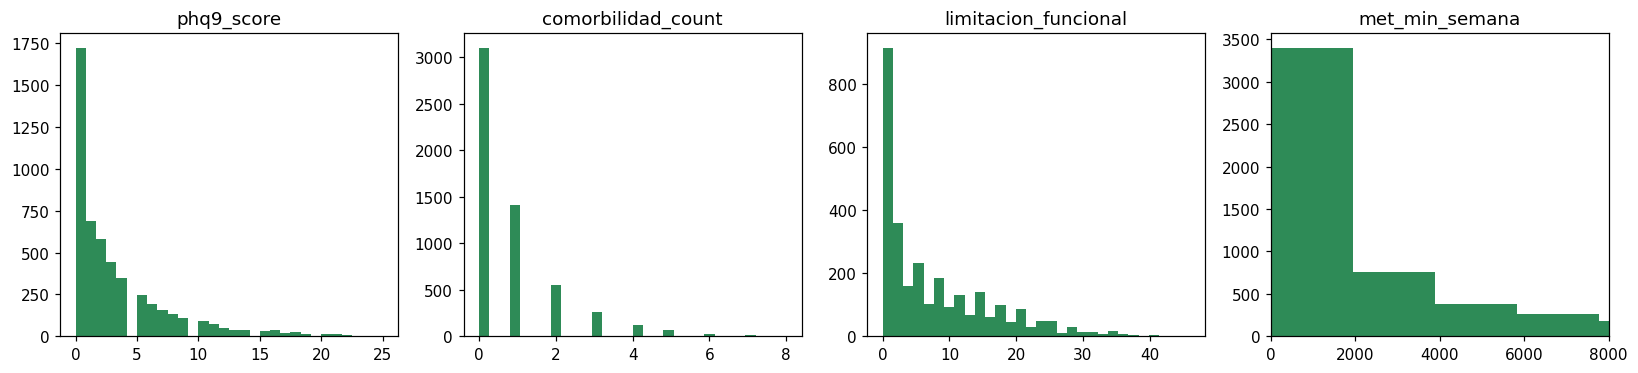

In [22]:
# Grafico 1: distribucion de scores principales
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
for ax, c in zip(axes, ["phq9_score", "comorbilidad_count", "limitacion_funcional", "met_min_semana"]):
    ax.hist(pd.to_numeric(quest[c], errors="coerce").dropna(), bins=30, color="seagreen")
    ax.set_title(c)
axes[3].set_xlim(0, 8000)
plt.tight_layout(); plt.show()

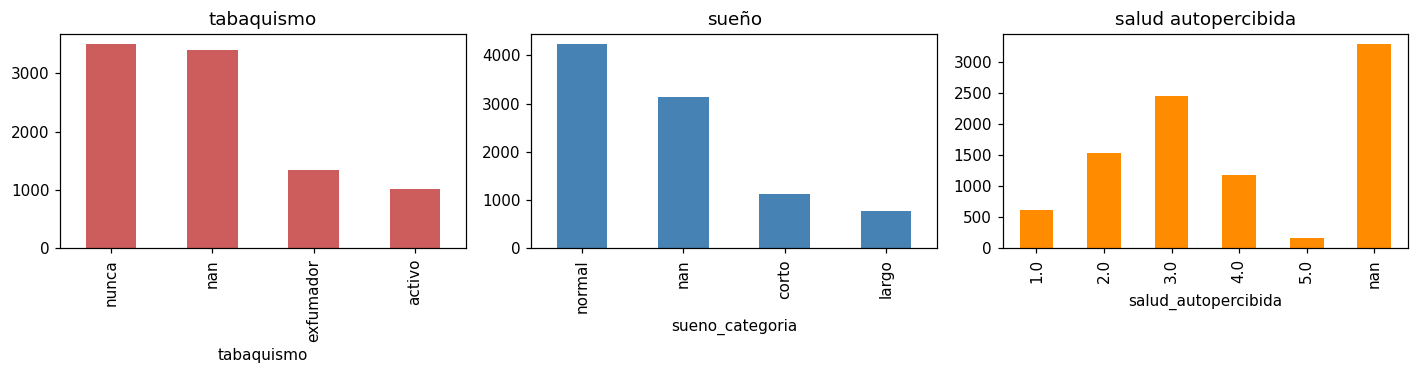

In [23]:
# Grafico 2: conteos de variables categoricas
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
quest["tabaquismo"].value_counts(dropna=False).plot.bar(ax=axes[0], color="indianred", title="tabaquismo")
quest["sueno_categoria"].value_counts(dropna=False).plot.bar(ax=axes[1], color="steelblue", title="sueño")
quest["salud_autopercibida"].value_counts(dropna=False).sort_index().plot.bar(ax=axes[2], color="darkorange", title="salud autopercibida")
plt.tight_layout(); plt.show()

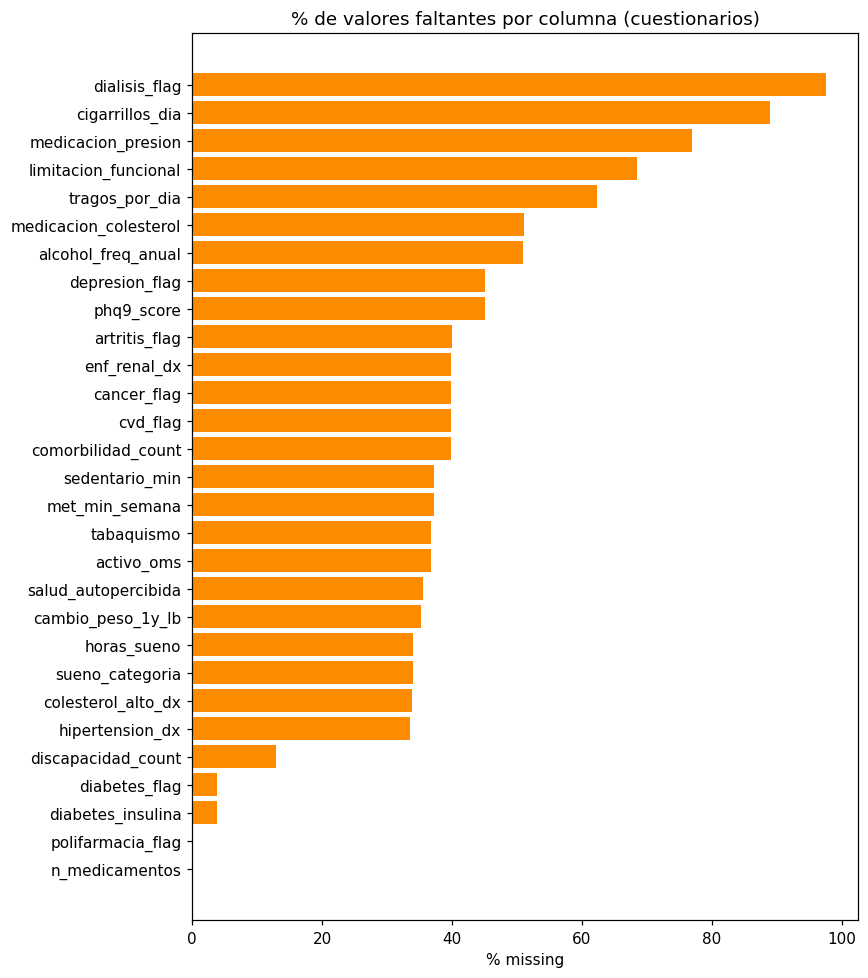

,%_missing
dialisis_flag,97.6
cigarrillos_dia,89.0
medicacion_presion,76.9
limitacion_funcional,68.5
tragos_por_dia,62.3
medicacion_colesterol,51.0
alcohol_freq_anual,50.9
depresion_flag,45.0
phq9_score,45.0
artritis_flag,40.0


In [24]:
# Grafico 3: % missing por columna
miss = (quest.isna().mean() * 100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 9))
ax.barh(miss.index[::-1], miss.values[::-1], color="darkorange")
ax.set_title("% de valores faltantes por columna (cuestionarios)")
ax.set_xlabel("% missing"); plt.tight_layout(); plt.show()
miss.round(1).to_frame("%_missing")

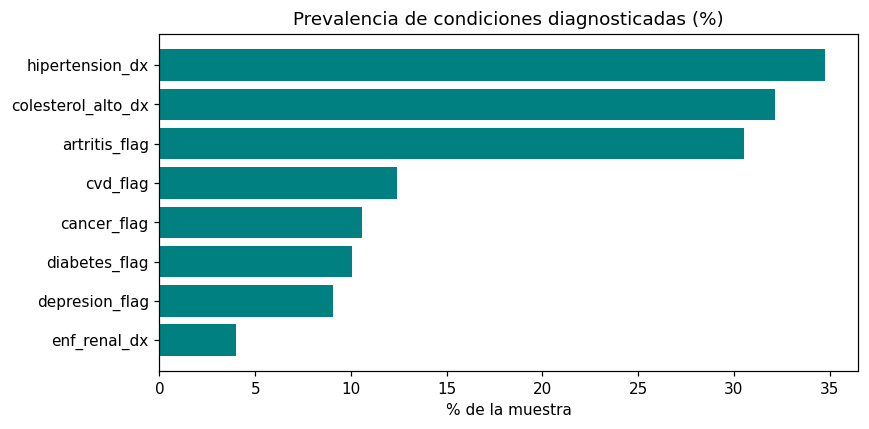

In [25]:
# Grafico 4: prevalencia de condiciones/flags clave
flags = ["hipertension_dx", "colesterol_alto_dx", "diabetes_flag", "cvd_flag",
         "cancer_flag", "artritis_flag", "enf_renal_dx", "depresion_flag"]
prev = {c: pd.to_numeric(quest[c], errors="coerce").mean() for c in flags}
prev = pd.Series(prev).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(prev.index, prev.values * 100, color="teal")
ax.set_title("Prevalencia de condiciones diagnosticadas (%)")
ax.set_xlabel("% de la muestra"); plt.tight_layout(); plt.show()

## 7. Exportación a `02_intermediate`

In [26]:
out_path = OUT_DIR / "quest_intermediate.parquet"
quest.to_parquet(out_path)
print("Guardado:", out_path, "| shape:", quest.shape)
print("Columnas:", list(quest.columns))
quest.head()

Guardado: C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\data\02_intermediate\quest_intermediate.parquet | shape: (9254, 29)
Columnas: ['tabaquismo', 'cigarrillos_dia', 'alcohol_freq_anual', 'tragos_por_dia', 'salud_autopercibida', 'met_min_semana', 'activo_oms', 'sedentario_min', 'limitacion_funcional', 'phq9_score', 'depresion_flag', 'horas_sueno', 'sueno_categoria', 'comorbilidad_count', 'cvd_flag', 'cancer_flag', 'artritis_flag', 'diabetes_flag', 'diabetes_insulina', 'hipertension_dx', 'medicacion_presion', 'colesterol_alto_dx', 'medicacion_colesterol', 'enf_renal_dx', 'dialisis_flag', 'n_medicamentos', 'polifarmacia_flag', 'cambio_peso_1y_lb', 'discapacidad_count']


,tabaquismo,cigarrillos_dia,alcohol_freq_anual,tragos_por_dia,salud_autopercibida,met_min_semana,activo_oms,sedentario_min,limitacion_funcional,phq9_score,depresion_flag,horas_sueno,sueno_categoria,comorbilidad_count,cvd_flag,cancer_flag,artritis_flag,diabetes_flag,diabetes_insulina,hipertension_dx,medicacion_presion,colesterol_alto_dx,medicacion_colesterol,enf_renal_dx,dialisis_flag,n_medicamentos,polifarmacia_flag,cambio_peso_1y_lb,discapacidad_count
SEQN,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
93705,exfumador,NaN,7.0,1.0,3.0,480.0,0,300.0,0.0,0.0,0,8.0,normal,1.0,0.0,0.0,1.0,0,0.0,1.0,1.0,0.0,0.0,0.0,NaN,3.0,0,0.0,0.0
93706,nunca,NaN,NaN,NaN,2.0,1140.0,1,240.0,NaN,0.0,0,10.5,largo,NaN,NaN,NaN,NaN,0,0.0,0.0,NaN,0.0,0.0,NaN,NaN,0.0,0,0.0,0.0
93707,NaN,NaN,NaN,NaN,3.0,NaN,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,0.0
93708,nunca,NaN,NaN,NaN,3.0,600.0,1,120.0,7.0,0.0,0,8.0,normal,1.0,0.0,0.0,1.0,0,0.0,1.0,1.0,1.0,1.0,0.0,NaN,3.0,0,0.0,0.0
93709,activo,5.0,NaN,NaN,NaN,1440.0,1,600.0,16.0,NaN,<NA>,7.0,normal,2.0,1.0,0.0,1.0,0,0.0,1.0,1.0,0.0,0.0,0.0,NaN,4.0,0,-10.0,2.0


## 8. Conclusiones del grupo Questionnaire

- De **14 cuestionarios** (cientos de columnas) llegamos a una tabla compacta de **indicadores
  y scores** clínicamente interpretables.
- Recodificamos los **códigos especiales NHANES** (7/9/777…) a `NaN` antes de cualquier cálculo.
- Construimos scores compuestos: **PHQ-9**, **índice de comorbilidad**, **score de limitación
  funcional**, **MET-min/semana**, conteo de discapacidad, estado de tabaquismo, etc.
- Etiquetamos los **marcadores de enfermedad terminal** (diálisis, polifarmacia, pérdida de peso,
  cáncer) como posible *leakage* para entrenar variantes con/sin ellos.
- Sin imputación/escalado (se hace post-split para evitar fuga de información).

### Referencias
- Kroenke, K., Spitzer, R. L., & Williams, J. B. (2001). *The PHQ-9.* J Gen Intern Med.
- OMS (2020). *Directrices sobre actividad física y comportamientos sedentarios.*
- CDC/NCHS. *NHANES 2017-2018 Questionnaire Data — Documentation & Codebooks.*
